# DataLab Cup3: Reverse Image Caption
TEAM 05 | 112021130 黃偉寧 | 112062313 柯俊安 | 112060002 羅詠璿 | 112062308 蔡佳倩

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

1. Pick 5 descriptions from testing data and generate 5 images with different noise $z$ respectively

In [2]:
# Test IDs and their descriptions
test_samples = {
    6735: "this white and purple flower has fragile petals and soft stamens",
    6740: "this flower has four large wide pink petals with white centers and vein like markings",
    6746: "a flower with broad white and pink ribbed petals and yellow stamen",
    6759: "one prominet pistil with alarger stigam and many stamens with anthers",
    6762: "leaves are green in color petals are light pink in color"
}

variations_dir = './inference_variations'
num_variations = 5

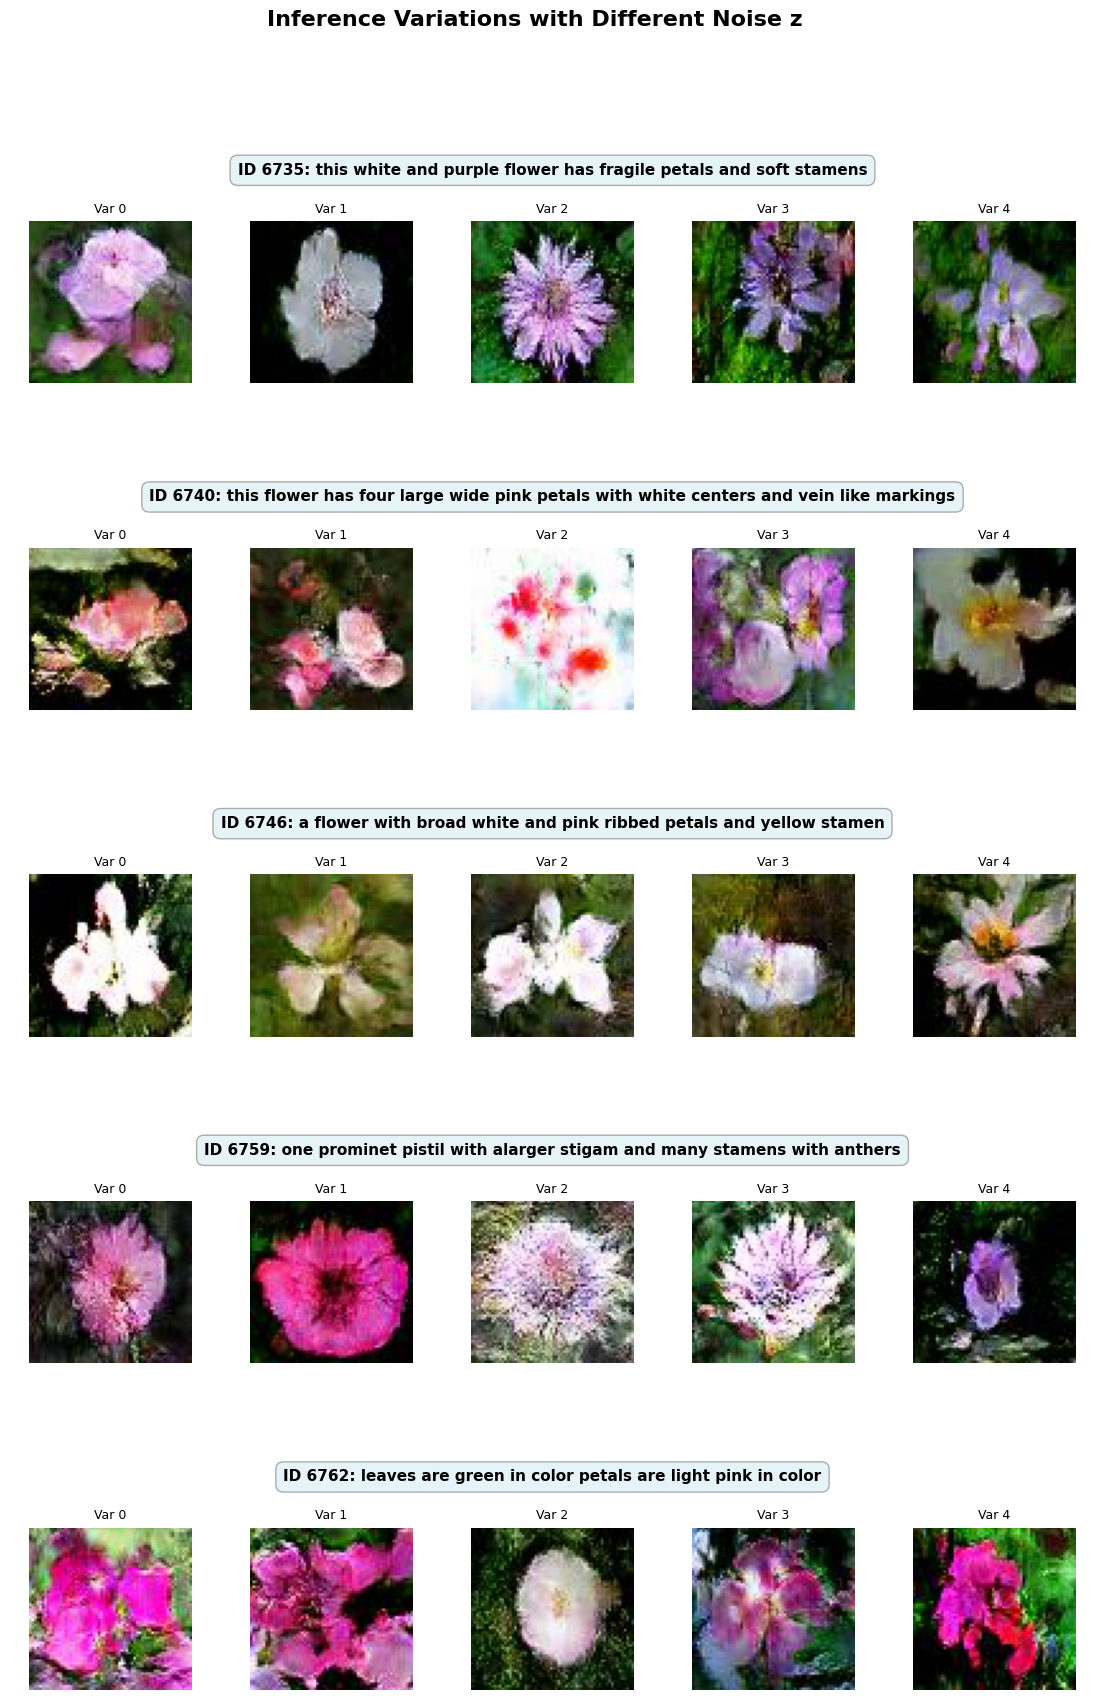

In [6]:
# Use Nested GridSpec for perfect alignment
# Outer Grid: 5 rows (one per sample)
# Inner Grid: 2 rows (Text + Images) per sample

fig = plt.figure(figsize=(14, 20)) # Increased height for better spacing
outer = GridSpec(len(test_samples), 1, figure=fig, hspace=0.4) 

for idx, (test_id, description) in enumerate(test_samples.items()):
    # Create inner grid for this sample: 
    # Row 0: Title (Height ratio 0.2) - More space for text
    # Row 1: 5 Images (Height ratio 0.8)
    # hspace=0.3: Much larger gap between text and images
    inner = outer[idx].subgridspec(2, 5, height_ratios=[0.2, 0.8], wspace=0.1, hspace=0.3)
    
    # --- 1. Title Section (Spans all 5 columns) ---
    ax_text = fig.add_subplot(inner[0, :])
    ax_text.axis('off')
    
    title_text = f"ID {test_id}: {description}"
    # Place text in the center of the text-box area
    ax_text.text(0.5, 0.5, title_text, 
                 ha='center', va='center', 
                 fontsize=11, weight='bold',
                 wrap=True,
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.3))
    
    # --- 2. Image Section (5 columns) ---
    for var_idx in range(num_variations):
        ax_img = fig.add_subplot(inner[1, var_idx])
        
        filename = f'idx_{test_id}_var_{var_idx}.jpg'
        filepath = os.path.join(variations_dir, filename)
        
        if os.path.exists(filepath):
            img = mpimg.imread(filepath)
            ax_img.imshow(img)
            ax_img.set_title(f'Var {var_idx}', fontsize=9)
        else:
            ax_img.text(0.5, 0.5, 'Not\\nFound', ha='center', va='center', fontsize=8)
            ax_img.set_title(f'Var {var_idx}', fontsize=9)
            
        ax_img.axis('off')

fig.suptitle('Inference Variations with Different Noise z', 
             fontsize=16, fontweight='bold', y=0.95) # Lowered title slightly

# No tight_layout() needed as GridSpec handles it
plt.show()

2. Models you tried during competition. Briefly describe the main idea of the model and the reason you chose that model.

1. Model Overview: Conditional WGAN-GP with FiLM and Projection Discriminator
為了在有限的運算資源與時間內達到收斂穩定且圖文相符的生成效果，我們採用了基於 WGAN-GP (Wasserstein GAN with Gradient Penalty) 的架構，並結合了 Pre-trained T5 Transformer 作為文本編碼器。

2. Key Architecture Components:

* Text Encoder (T5-base):
    Unlike traditional RNN or LSTM encoders, we utilized the T5-base (Text-to-Text Transfer Transformer) model to extract high-dimensional semantic embeddings from the input captions. T5 offers superior language understanding, ensuring that the complex semantic nuances of the text are captured before being passed to the GAN.

* Generator with FiLM (Feature-wise Linear Modulation):
    The Generator is built upon Residual Up-Sampling Blocks. To effectively condition the image generation process on the text description, we implemented FiLM (Feature-wise Linear Modulation) layers. FiLM applies an affine transformation to the feature maps based on the text embeddings, allowing the linguistic features to influence the visual synthesis at various hierarchical levels (coarse to fine).

* Discriminator with Projection Mechanism:
    The Discriminator uses Residual Down-Sampling Blocks. Crucially, we implemented the Projection Discriminator technique (Miyato et al.). Instead of simply concatenating text and image vectors, the Projection Discriminator computes the inner product between the image feature vector and the text embedding. This explicitly measures the alignment between the generated image and the given text condition.

* Loss Function (WGAN-GP):
    To combat mode collapse and training instability common in GANs, we employed the Wasserstein loss with Gradient Penalty. This provides a smoother gradient flow and more stable convergence compared to the standard Min-Max GAN loss.

3. Reason for choosing this model:

* Training Stability: Given the time constraints, WGAN-GP offers a more robust training process with less hyperparameter tuning required compared to vanilla GANs.
* Semantic Consistency: The combination of T5 embeddings and the Projection Discriminator ensures that the model focuses heavily on semantic alignment, which is critical for the text-to-image task.
* Feature Fusion Efficiency: The FiLM mechanism is a computationally efficient way to modulate visual features with text information without significantly increasing the parameter count, making it suitable for our resource budget.

3. List the experiment you did. For example, data augmentation, hyper-parameters tuning, architecture tuning, optimizer tuning, and so on.

很遺憾地，我們投注了大把時間在 stable diffusion 上但沒有成功，當啟動 WGAN-GP 備案時時間已經所剩無幾，故僅做了以下嘗試：

1. Data Augmentation
To prevent overfitting on the limited dataset and improve the discriminator's robustness, we applied specific augmentation techniques during the training pipeline:
* Random Horizontal Flip: Applied with a probability of $0.4$. This helps the model learn orientation invariance.
* Random Brightness: Adjusted with a `max_delta` of $0.2$ and a probability of $0.4$. This encourages the generator to produce images with varied lighting conditions rather than memorizing dataset statistics.

2. Hyper-parameters Tuning & Optimization Strategy
We adopted stability-focused hyperparameters derived from WGAN-GP literature to ensure training stability without extensive tuning:
* Two-Time-Scale Update Rule (TTUR): We used different learning rates for the generator ($1e-4$) and the discriminator ($4e-4$). This imbalance allows the discriminator to learn faster, providing more meaningful gradients to the generator.
* WGAN-GP Constraints:
    * Gradient Penalty Lambda: Set to $10$ to enforce the 1-Lipschitz constraint.
    * Critic Iterations ($n_{critic}$): We trained the discriminator $7$ times for every $1$ generator step (Standard WGAN usually uses 5). This stricter training of the critic ensured a more accurate Wasserstein distance estimation.
* Optimizer: We used the Adam optimizer with $\beta_1 = 0.0$ and $\beta_2 = 0.9$. Setting $\beta_1$ to $0$ is a crucial "trick" for WGAN-GP stability that we adopted from the start.

3. Results of Preliminary Experiments
* Initial Baseline: Our initial robust configuration (WGAN-GP + T5 + Augmentation) immediately achieved a evaluation score of 0.5, demonstrating the effectiveness of combining these advanced techniques even without prolonged hyperparameter sweeping.